# Suite 4 — Physics vs Machine Learning Residuals

**Goal:** isolate what the ML learns *on top of* the deterministic physical simulation.

Sources: `data/processed/ml_training_matrix.parquet` (physical priors + weather + CF targets) and `results/macro_oof_predictions.parquet` (LightGBM out-of-fold predictions). ML residual := `pred_cf − prior_cf` — the correction the model applies to the physics.

In [2]:
import os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Anchor to repo root so relative data/results paths work whether the notebook
# is launched from notebooks/ or the project root.
ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
os.chdir(ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "axes.titleweight": "bold", "axes.grid": True, "grid.alpha": 0.3,
})
FIG = "results/figures"
os.makedirs(FIG, exist_ok=True)

def save(fig, name):
    p = os.path.join(FIG, name)
    fig.savefig(p)
    print("saved ->", p)
    return p

# Consistent model palette across every suite.
MODEL_ORDER = ["persistence", "climatology", "lightgbm", "xgboost", "ebm", "bilstm", "tft"]
PAL = dict(zip(MODEL_ORDER, sns.color_palette("colorblind", len(MODEL_ORDER))))
BASELINES = {"persistence", "climatology"}


In [3]:
mat = pd.read_parquet("data/processed/ml_training_matrix.parquet")
mat.index = pd.to_datetime(mat.index, utc=True)
oof = pd.read_parquet("results/macro_oof_predictions.parquet")
oof["timestamp"] = pd.to_datetime(oof["timestamp"], utc=True)
TARGET = {"wind": "wind_cf_50hz", "solar": "solar_cf_50hz"}
PRIOR = {"wind": "wind_prior_cf", "solar": "solar_prior_cf"}

## 4a — Raw physical prior vs target (deterministic baseline skill)

saved -> results/figures/s4_prior_vs_target.png


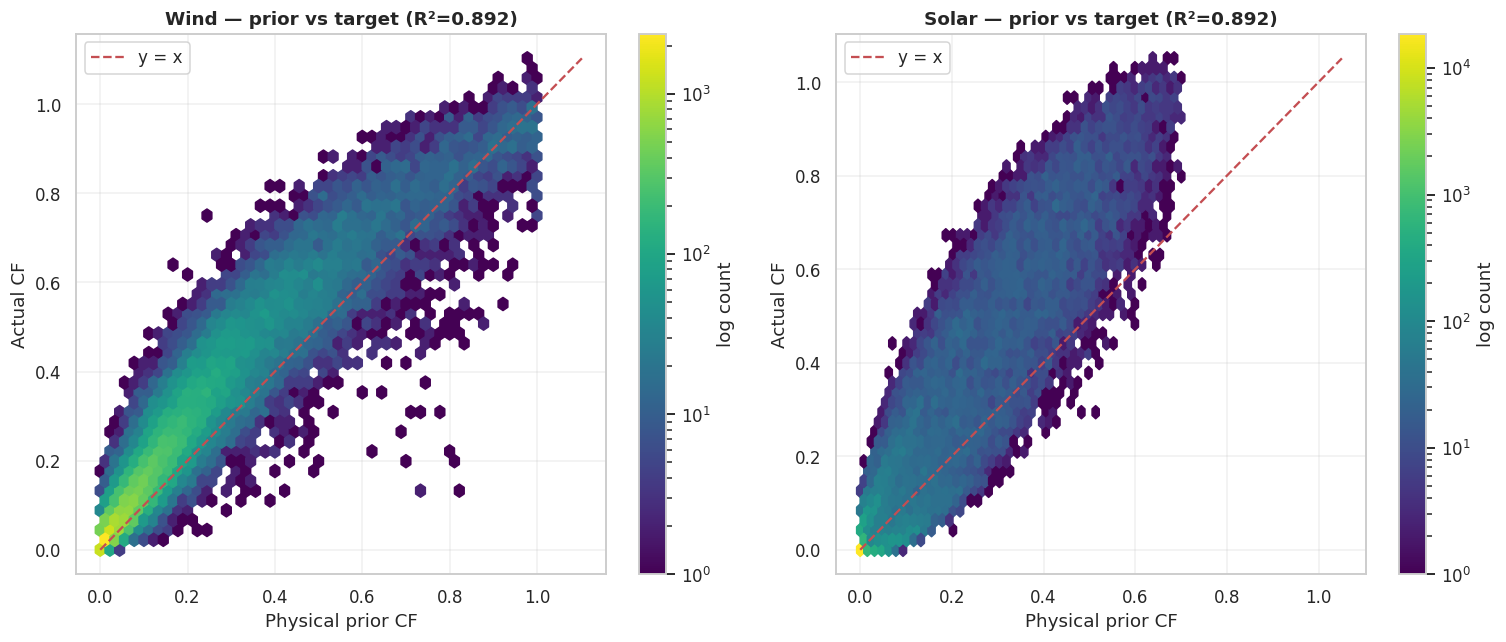

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, tech in zip(axes, ["wind","solar"]):
    x = mat[PRIOR[tech]]; y = mat[TARGET[tech]]
    ok = x.notna() & y.notna()
    hb = ax.hexbin(x[ok], y[ok], gridsize=45, cmap="viridis", mincnt=1, bins="log")
    lim = [0, max(x[ok].max(), y[ok].max())]
    ax.plot(lim, lim, "r--", lw=1.5, label="y = x")
    rr = np.corrcoef(x[ok], y[ok])[0,1] ** 2
    ax.set_title(f"{tech.title()} — prior vs target (R²={rr:.3f})")
    ax.set_xlabel("Physical prior CF"); ax.set_ylabel("Actual CF"); ax.legend(loc="upper left")
    fig.colorbar(hb, ax=ax, label="log count")
fig.tight_layout(); save(fig, "s4_prior_vs_target.png"); plt.show()

## 4b — ML residual (pred − prior) vs meteorology

If the ML is a thermodynamic error-correction layer, its correction to the physics should be structured against temperature and pressure — not noise.

saved -> results/figures/s4_ml_residual_vs_meteo.png


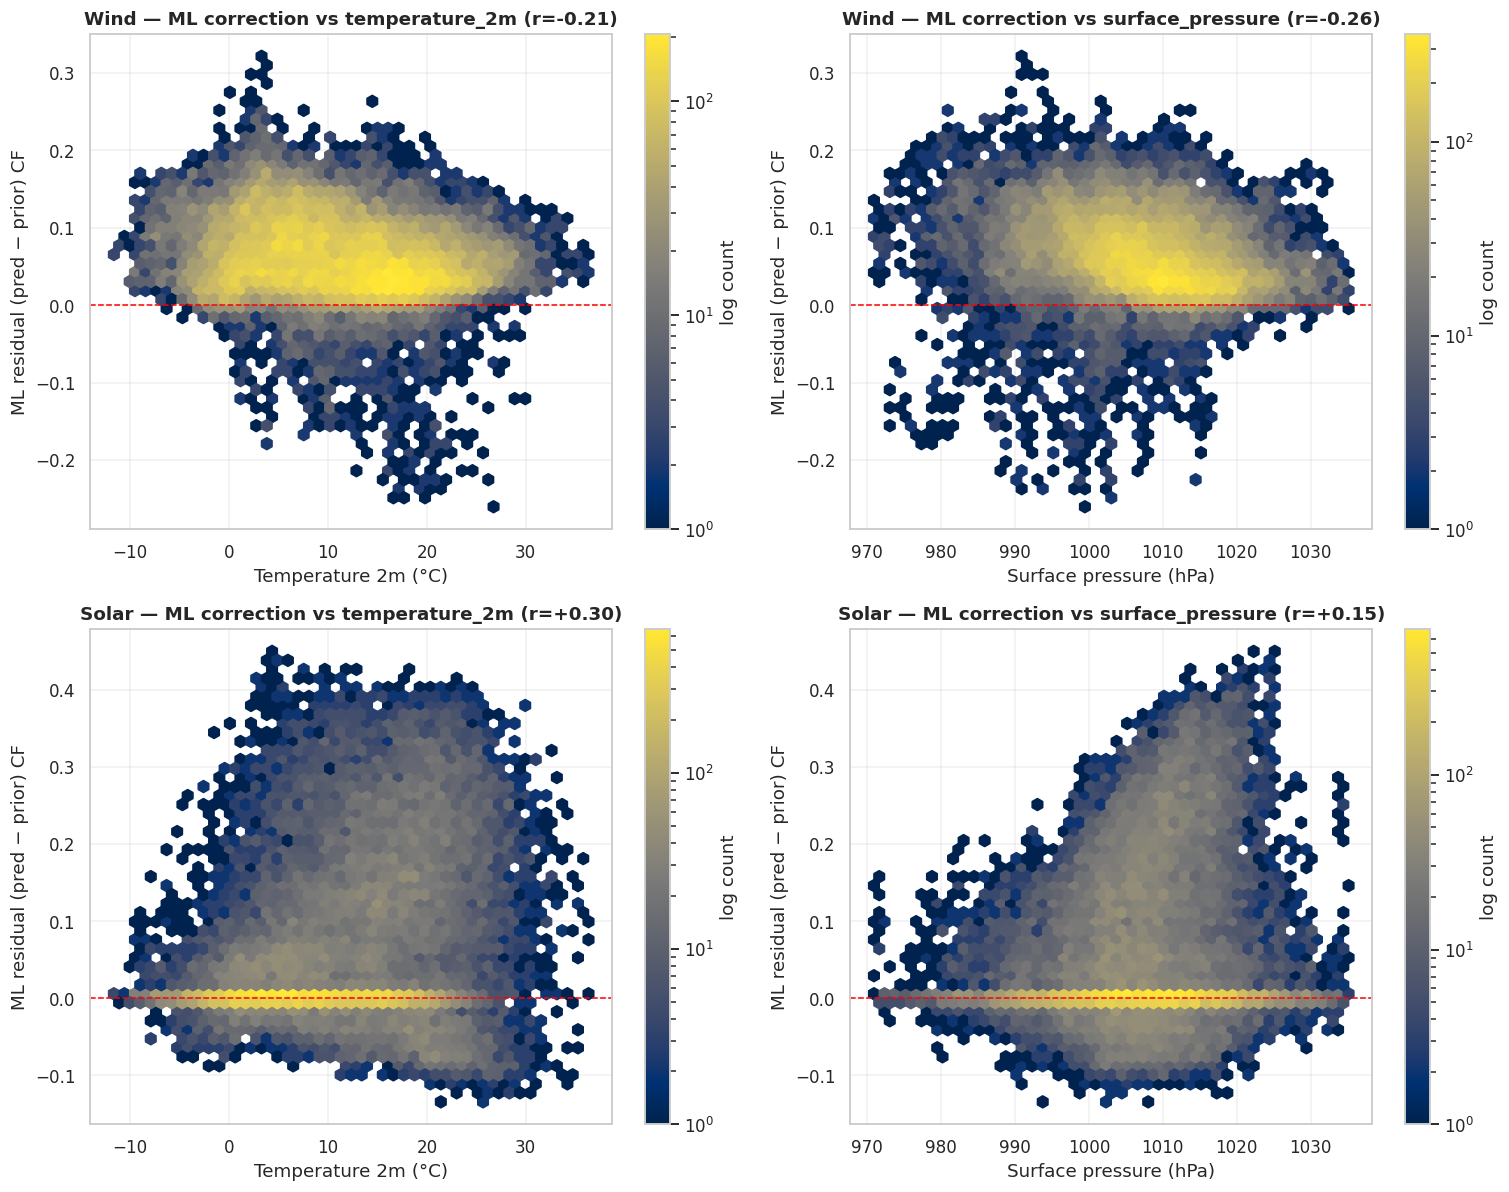

In [5]:
lgb = oof[oof.model == "lightgbm"].copy()
lgb["ml_resid"] = lgb["pred_cf"] - lgb["prior_cf"]
met = mat[["temperature_2m","surface_pressure","relative_humidity_2m"]]
lgb = lgb.merge(met, left_on="timestamp", right_index=True, how="left")

feats = [("temperature_2m","Temperature 2m (°C)"), ("surface_pressure","Surface pressure (hPa)")]
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for r, tech in enumerate(["wind","solar"]):
    g = lgb[lgb.technology == tech]
    for c, (f, flabel) in enumerate(feats):
        ax = axes[r, c]
        ok = g[f].notna() & g["ml_resid"].notna()
        hb = ax.hexbin(g.loc[ok, f], g.loc[ok, "ml_resid"], gridsize=45, cmap="cividis", mincnt=1, bins="log")
        rho = np.corrcoef(g.loc[ok, f], g.loc[ok, "ml_resid"])[0,1]
        ax.axhline(0, color="red", ls="--", lw=1)
        ax.set_title(f"{tech.title()} — ML correction vs {f} (r={rho:+.2f})")
        ax.set_xlabel(flabel); ax.set_ylabel("ML residual (pred − prior) CF")
        fig.colorbar(hb, ax=ax, label="log count")
fig.tight_layout(); save(fig, "s4_ml_residual_vs_meteo.png"); plt.show()

## 4c — Correlation of the ML correction with meteorological drivers

saved -> results/figures/s4_ml_residual_correlation.png


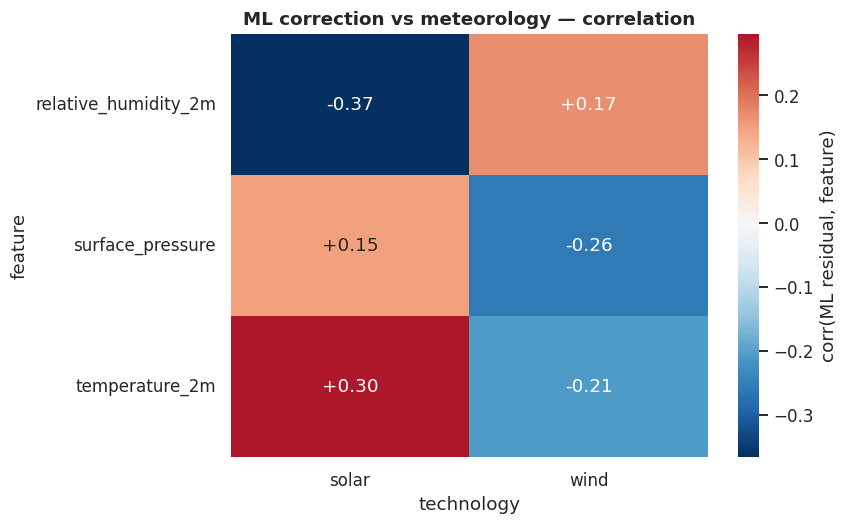

technology,solar,wind
feature,,
relative_humidity_2m,-0.366099,0.171687
surface_pressure,0.150065,-0.259625
temperature_2m,0.296139,-0.206484


In [6]:
rows = []
for tech in ["wind","solar"]:
    g = lgb[lgb.technology == tech]
    for f in ["temperature_2m","surface_pressure","relative_humidity_2m"]:
        ok = g[f].notna() & g["ml_resid"].notna()
        rows.append(dict(technology=tech, feature=f,
                         corr=np.corrcoef(g.loc[ok, f], g.loc[ok, "ml_resid"])[0,1]))
cdf = pd.DataFrame(rows).pivot(index="feature", columns="technology", values="corr")
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cdf, annot=True, fmt="+.2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label":"corr(ML residual, feature)"})
ax.set_title("ML correction vs meteorology — correlation")
save(fig, "s4_ml_residual_correlation.png"); plt.show(); cdf